In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_excel('данные_мобикар.xlsx')
df = df[df['Дата'] != 'ИТОГО'].copy()
df.head()

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,Неделя 1,206,130,91,70,57,51
1,07.01.2025,Неделя 1,216,138,98,73,55,48
2,08.01.2025,Неделя 1,181,117,86,69,52,46
3,09.01.2025,Неделя 1,212,134,101,83,64,54
4,10.01.2025,Неделя 1,218,143,97,73,60,53


In [32]:
df.describe()

,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
count,56.00000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,206.37500,138.303571,91.625000,73.500000,57.464286,50.410714
std,14.39768,10.560509,13.054519,10.493288,8.351297,7.248264
min,181.00000,117.000000,64.000000,53.000000,42.000000,36.000000
25%,195.50000,131.750000,82.750000,65.750000,52.000000,45.750000
50%,206.50000,138.500000,94.000000,74.000000,58.000000,51.000000
75%,215.25000,146.250000,98.750000,81.000000,62.000000,55.000000
max,238.00000,161.000000,117.000000,99.000000,82.000000,69.000000


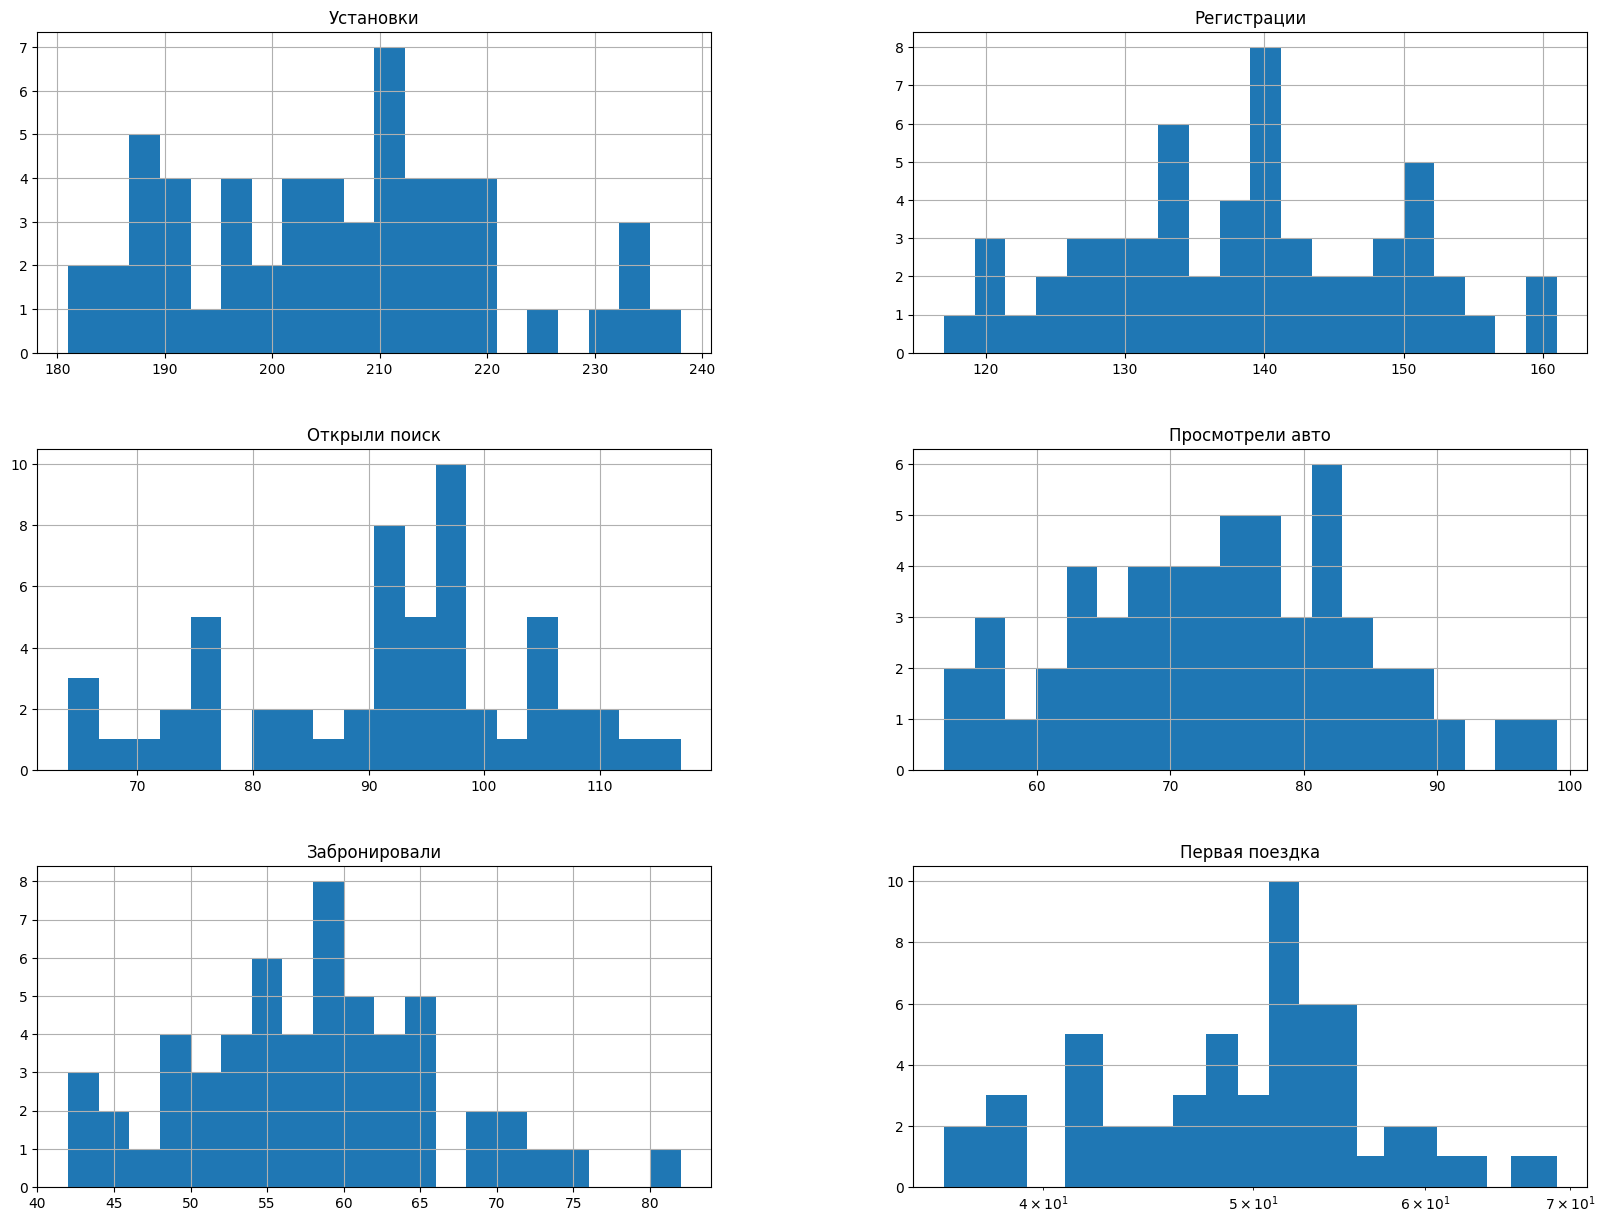

In [33]:
df_float64 = df.select_dtypes(include = "int64")
df_float64.hist(bins=20, figsize=(20, 15))
plt.xscale('log')
plt.show()

In [34]:
funnel_cols = ["Установки", "Регистрации", "Открыли поиск", "Просмотрели авто", "Забронировали", "Первая поездка"]
weekly = df.groupby("Неделя")[funnel_cols].sum()

In [35]:
# Ключевой этап:
weekly["Конверсия install → first trip (%)"] = (
    weekly["Первая поездка"] / weekly["Установки"] * 100
)

weekly["Конверсия registration → search (%)"] = (
    weekly["Открыли поиск"] / weekly["Регистрации"] * 100
)

weekly["Install → Registration (%)"] = (
    weekly["Регистрации"] / weekly["Установки"] * 100
)

weekly["Search → Car View (%)"] = (
    weekly["Просмотрели авто"] / weekly["Открыли поиск"] * 100
)

weekly["View → Booking (%)"] = (
    weekly["Забронировали"] / weekly["Просмотрели авто"] * 100
)

weekly["Booking → First Trip (%)"] = (
    weekly["Первая поездка"] / weekly["Забронировали"] * 100
)

weekly.round(2)

,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка,Конверсия install → first trip (%),Конверсия registration → search (%),Install → Registration (%),Search → Car View (%),View → Booking (%),Booking → First Trip (%)
Неделя,,,,,,,,,,,,
Неделя 1,1458,953,689,547,430,374,25.65,72.30,65.36,79.39,78.61,86.98
Неделя 2,1415,933,661,522,411,368,26.01,70.85,65.94,78.97,78.74,89.54
Неделя 3,1433,973,721,581,440,379,26.45,74.10,67.90,80.58,75.73,86.14
Неделя 4,1407,956,688,549,415,364,25.87,71.97,67.95,79.80,75.59,87.71
Неделя 5,1433,956,696,556,440,383,26.73,72.80,66.71,79.89,79.14,87.05
Неделя 6,1357,922,653,516,411,373,27.49,70.82,67.94,79.02,79.65,90.75
Неделя 7,1526,1021,504,424,336,283,18.55,49.36,66.91,84.13,79.25,84.23
Неделя 8,1528,1031,519,421,335,299,19.57,50.34,67.47,81.12,79.57,89.25


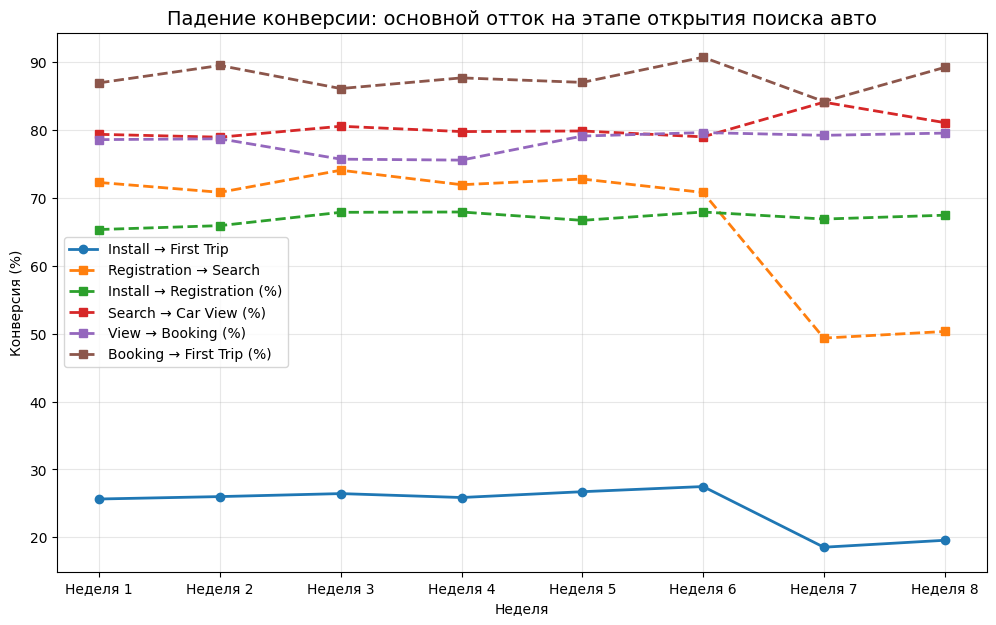

In [36]:
plt.figure(figsize=(12, 7))

# Общая конверсия
plt.plot(
    weekly.index,
    weekly["Конверсия install → first trip (%)"],
    marker="o",
    linewidth=2,
    label="Install → First Trip"
)

# Ключевой этап оттока
plt.plot(
    weekly.index,
    weekly["Конверсия registration → search (%)"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Registration → Search"
)

plt.plot(
    weekly.index,
    weekly["Install → Registration (%)"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Install → Registration (%)"
)

plt.plot(
    weekly.index,
    weekly["Search → Car View (%)"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Search → Car View (%)"
)

plt.plot(
    weekly.index,
    weekly["View → Booking (%)"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="View → Booking (%)"
)

plt.plot(
    weekly.index,
    weekly["Booking → First Trip (%)"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Booking → First Trip (%)"
)

plt.title(
    "Падение конверсии: основной отток на этапе открытия поиска авто",
    fontsize=14
)

plt.xlabel("Неделя")
plt.ylabel("Конверсия (%)")
plt.legend()
plt.grid(True, alpha=0.3)

Видим, что основная проблема возникла на этапе поиска авто: здесь фиксируются падение конверсии при примерно неизменной ситуации на остальных этапах.